# Evaluación final — Reseñas de vinos

**Módulo 06 — Fundamentos de redes neuronales.** Resolución del cuestionario final sobre el dataset `winemag-data-130k-v2.csv`. El enunciado completo está en [`enunciado.md`](enunciado.md).

## Cómo usar esta notebook

El dataset **no está versionado** en el repositorio (los archivos de datos pesados están en el `.gitignore`). Antes de ejecutar, descargalo del repositorio de GitHub del curso y dejalo en:

```
practica/evaluacion-final/datasets/winemag-data-130k-v2.csv
```

## Plan de trabajo

1. Carga y exploración inicial.
2. Copia del original y eliminación de columnas.
3. `data_eliminados`: descarte de nulos y codificación de etiquetas.
4. `data_imputados`: imputación de `points` y `price`, descarte del resto de nulos y codificación.
5. División 70/30 con semilla 17 en ambos conjuntos.
6. Modelos y evaluación, a medida que el cuestionario los pida.

## 1. Librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split

RANDOM_STATE = 17   # semilla pedida por el enunciado
TEST_SIZE = 0.3     # division 70/30

pd.set_option('display.max_columns', None)

## 2. Carga del dataset

Se carga el archivo original y se lo deja intacto en `datos`. Todo el trabajo posterior se hace sobre copias.

In [2]:
RUTA = 'datasets/winemag-data-130k-v2.csv'

datos = pd.read_csv(RUTA)
print(f'Filas: {datos.shape[0]:,} | Columnas: {datos.shape[1]}')
datos.head()

Filas: 129,971 | Columnas: 14


,Unnamed: 0,country,description,designation,points,price,province,region_1,region_2,taster_name,taster_twitter_handle,title,variety,winery
0,0,Italy,"Aromas include tropical fruit, broom, brimston...",Vulkà Bianco,87,NaN,Sicily & Sardinia,Etna,NaN,Kerin O’Keefe,@kerinokeefe,Nicosia 2013 Vulkà Bianco (Etna),White Blend,Nicosia
1,1,Portugal,"This is ripe and fruity, a wine that is smooth...",Avidagos,87,15.0,Douro,NaN,NaN,Roger Voss,@vossroger,Quinta dos Avidagos 2011 Avidagos Red (Douro),Portuguese Red,Quinta dos Avidagos
2,2,US,"Tart and snappy, the flavors of lime flesh and...",NaN,87,14.0,Oregon,Willamette Valley,Willamette Valley,Paul Gregutt,@paulgwine,Rainstorm 2013 Pinot Gris (Willamette Valley),Pinot Gris,Rainstorm
3,3,US,"Pineapple rind, lemon pith and orange blossom ...",Reserve Late Harvest,87,13.0,Michigan,Lake Michigan Shore,NaN,Alexander Peartree,NaN,St. Julian 2013 Reserve Late Harvest Riesling ...,Riesling,St. Julian
4,4,US,"Much like the regular bottling from 2012, this...",Vintner's Reserve Wild Child Block,87,65.0,Oregon,Willamette Valley,Willamette Valley,Paul Gregutt,@paulgwine,Sweet Cheeks 2012 Vintner's Reserve Wild Child...,Pinot Noir,Sweet Cheeks


### Exploración inicial

Antes de tocar nada conviene ver los tipos de dato y el panorama de valores ausentes: de eso dependen las dos estrategias que compara el cuestionario.

In [3]:
datos.info()

<class 'pandas.DataFrame'>
RangeIndex: 129971 entries, 0 to 129970
Data columns (total 14 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Unnamed: 0             129971 non-null  int64  
 1   country                129908 non-null  str    
 2   description            129971 non-null  str    
 3   designation            92506 non-null   str    
 4   points                 129971 non-null  int64  
 5   price                  120975 non-null  float64
 6   province               129908 non-null  str    
 7   region_1               108724 non-null  str    
 8   region_2               50511 non-null   str    
 9   taster_name            103727 non-null  str    
 10  taster_twitter_handle  98758 non-null   str    
 11  title                  129971 non-null  str    
 12  variety                129970 non-null  str    
 13  winery                 129971 non-null  str    
dtypes: float64(1), int64(2), str(11)
memory usage: 

In [4]:
nulos = datos.isnull().sum().sort_values(ascending=False)
pd.DataFrame({
    'nulos': nulos,
    'porcentaje': (nulos / len(datos) * 100).round(2)
})

,nulos,porcentaje
region_2,79460,61.14
designation,37465,28.83
taster_twitter_handle,31213,24.02
taster_name,26244,20.19
region_1,21247,16.35
price,8996,6.92
country,63,0.05
province,63,0.05
variety,1,0.00
Unnamed: 0,0,0.00


## 3. Copia y eliminación de columnas

Según el enunciado: copia profunda del original y descarte de `region_2`, `taster_twitter_handle`, `designation` y `Unnamed: 0`.

`copy(deep=True)` crea una copia independiente: modificar `datos_copy` no altera `datos`.

In [5]:
datos_copy = datos.copy(deep = True)

columnas_a_eliminar = ['region_2', 'taster_twitter_handle', 'designation', 'Unnamed: 0']
datos_copy = datos_copy.drop(columns=columnas_a_eliminar)

print('Columnas restantes:', list(datos_copy.columns))
print(f'Dimensiones: {datos_copy.shape}')

Columnas restantes: ['country', 'description', 'points', 'price', 'province', 'region_1', 'taster_name', 'title', 'variety', 'winery']
Dimensiones: (129971, 10)


## 4. `data_eliminados`

Estrategia de **descarte**: se eliminan todas las filas que tengan algún valor ausente y después se codifican las variables categóricas.

El orden importa: primero se descartan los nulos, después se codifica. Codificar antes obligaría a decidir qué hacer con los `NaN` dentro del encoder.

In [6]:
data_eliminados = datos_copy.dropna(axis=0)

print(f'Antes : {datos_copy.shape[0]:,} filas')
print(f'Despues: {data_eliminados.shape[0]:,} filas')
print(f'Se descarto el {(1 - len(data_eliminados)/len(datos_copy))*100:.2f}% de las filas')

Antes : 129,971 filas
Despues: 77,267 filas
Se descarto el 40.55% de las filas


> **Atención con este descarte.** No se pierden solo filas: se pierden **clases enteras**. La celda siguiente lo verifica.

In [7]:
paises_orig = datos_copy['country'].nunique()
paises_post = data_eliminados['country'].nunique()

print(f'Paises en el original      : {paises_orig}')
print(f'Paises tras eliminar nulos : {paises_post}')
print(f'\nDistribucion resultante:')
print(data_eliminados['country'].value_counts().to_string())

print(f"\nPaises con region_1 no nula: {datos_copy[datos_copy['region_1'].notna()]['country'].nunique()}")

Paises en el original      : 43
Paises tras eliminar nulos : 7

Distribucion resultante:
country
US           37255
France       17457
Italy        10096
Spain         6501
Argentina     3700
Australia     2005
Canada         253

Paises con region_1 no nula: 7


El culpable es **`region_1`**: solo está poblada para 7 países, así que al descartar las filas con algún ausente desaparecen los otros 36. El conjunto `data_eliminados` no es una muestra representativa del original, es el subconjunto de países que tienen región cargada.

Además, las 7 clases que quedan están **muy desbalanceadas**: US aporta unas 37.000 filas y Canadá apenas 253. Al evaluar la clasificación de `country`, la exactitud sola va a estar dominada por US — conviene mirar la matriz de confusión y el F1 por clase (cap. 8 del manual).

### Codificación de etiquetas

La **codificación de etiquetas** (`LabelEncoder`) asigna un entero a cada categoría. Se aplica a todas las columnas de tipo objeto.

> Nota: esta codificación introduce un orden numérico que no existe entre las categorías (que Argentina sea 1 y Australia 2 no significa que Australia sea "mayor"). Los modelos basados en árboles lo toleran bien; los modelos lineales y las redes neuronales pueden interpretarlo como una magnitud. El enunciado pide explícitamente esta codificación, así que se usa esta.

In [8]:
data_eliminados = data_eliminados.copy()

# Se codifican solo las columnas categoricas que se van a usar como feature o target.
# 'description' y 'title' son texto libre de altisima cardinalidad (casi un valor
# distinto por fila): codificarlas con etiquetas no aporta nada y solo gasta tiempo.
columnas_categoricas = ['country', 'province', 'region_1', 'taster_name', 'variety', 'winery']

encoders_eliminados = {}
for col in columnas_categoricas:
    le = LabelEncoder()
    data_eliminados[col] = le.fit_transform(data_eliminados[col])
    encoders_eliminados[col] = le

print('Codificadas:', columnas_categoricas)
data_eliminados.head()

Codificadas: ['country', 'province', 'region_1', 'taster_name', 'variety', 'winery']


,country,description,points,price,province,region_1,taster_name,title,variety,winery
2,6,"Tart and snappy, the flavors of lime flesh and...",87,14.0,43,1079,12,Rainstorm 2013 Pinot Gris (Willamette Valley),288,9309
3,6,"Pineapple rind, lemon pith and orange blossom ...",87,13.0,30,491,0,St. Julian 2013 Reserve Late Harvest Riesling ...,316,10215
4,6,"Much like the regular bottling from 2012, this...",87,65.0,43,1079,12,Sweet Cheeks 2012 Vintner's Reserve Wild Child...,292,10339
5,5,Blackberry and raspberry aromas show a typical...,87,15.0,39,663,11,Tandem 2011 Ars In Vitro Tempranillo-Merlot (N...,394,10396
6,4,"Here's a bright, informal red that opens with ...",87,16.0,49,1066,8,Terre di Giurfo 2013 Belsito Frappato (Vittoria),113,10603


### Separación de features y target

Target: `country`. Es un problema de **clasificación multiclase**.

In [9]:
features = ['price', 'points', 'province', 'region_1','taster_name','variety', 'winery']
target = 'country'

X_eliminados = data_eliminados[features]
y_eliminados = data_eliminados[target]

print(f'X_eliminados: {X_eliminados.shape}')
print(f'y_eliminados: {y_eliminados.shape} | clases distintas: {y_eliminados.nunique()}')

X_eliminados: (77267, 7)
y_eliminados: (77267,) | clases distintas: 7


## 5. `data_imputados`

Estrategia de **imputación**: se completan `points` con su mediana y `price` con su media, y recién después se descartan las filas que sigan teniendo ausentes en otras columnas.

- **Mediana** para `points`: es robusta a valores extremos.
- **Media** para `price`: es la que pide el enunciado.

> **Observación metodológica.** El target de este conjunto es `price`, y el enunciado pide imputarlo con la media antes de separarlo. Imputar la variable objetivo introduce filas cuyo valor real es desconocido y que el modelo aprende como si fueran observaciones válidas — se le enseña a predecir la media. Es una decisión discutible, pero es lo que pide la consigna, así que se sigue al pie de la letra. Vale tenerlo presente al interpretar las métricas.

In [10]:
data_imputados = datos_copy.copy(deep = True)

mediana_points = data_imputados['points'].median()
media_price = data_imputados['price'].mean()

print(f'Mediana de points: {mediana_points}')
print(f'Media de price   : {media_price:.4f}')

data_imputados['points'] = data_imputados['points'].fillna(mediana_points)
data_imputados['price'] = data_imputados['price'].fillna(media_price)

print(f"\nNulos restantes en points: {data_imputados['points'].isnull().sum()}")
print(f"Nulos restantes en price : {data_imputados['price'].isnull().sum()}")

Mediana de points: 88.0
Media de price   : 35.3634

Nulos restantes en points: 0
Nulos restantes en price : 0


Ahora sí, se descartan las filas que sigan teniendo ausentes en el resto de las columnas.

In [11]:
antes = data_imputados.shape[0]
data_imputados = data_imputados.dropna(axis=0)

print(f'Antes : {antes:,} filas')
print(f'Despues: {data_imputados.shape[0]:,} filas')
print(f'\nComparacion con la estrategia de descarte:')
print(f'  data_eliminados: {data_eliminados.shape[0]:,} filas')
print(f'  data_imputados : {data_imputados.shape[0]:,} filas')

Antes : 129,971 filas
Despues: 82,847 filas

Comparacion con la estrategia de descarte:
  data_eliminados: 77,267 filas
  data_imputados : 82,847 filas


### Codificación de etiquetas

In [12]:
data_imputados = data_imputados.copy()

columnas_categoricas_imp = ['country', 'province', 'region_1', 'taster_name', 'variety', 'winery']

encoders_imputados = {}
for col in columnas_categoricas_imp:
    le = LabelEncoder()
    data_imputados[col] = le.fit_transform(data_imputados[col])
    encoders_imputados[col] = le

print('Codificadas:', columnas_categoricas_imp)
data_imputados.head()

Codificadas: ['country', 'province', 'region_1', 'taster_name', 'variety', 'winery']


,country,description,points,price,province,region_1,taster_name,title,variety,winery
0,4,"Aromas include tropical fruit, broom, brimston...",87,35.363389,49,386,8,Nicosia 2013 Vulkà Bianco (Etna),465,8938
2,6,"Tart and snappy, the flavors of lime flesh and...",87,14.000000,43,1096,12,Rainstorm 2013 Pinot Gris (Willamette Valley),292,9860
3,6,"Pineapple rind, lemon pith and orange blossom ...",87,13.000000,30,499,0,St. Julian 2013 Reserve Late Harvest Riesling ...,320,10783
4,6,"Much like the regular bottling from 2012, this...",87,65.000000,43,1096,12,Sweet Cheeks 2012 Vintner's Reserve Wild Child...,296,10909
5,5,Blackberry and raspberry aromas show a typical...,87,15.000000,39,674,11,Tandem 2011 Ars In Vitro Tempranillo-Merlot (N...,400,10968


### Separación de features y target

Target: `price`. Es un problema de **regresión**.

In [13]:
features = ['country', 'points', 'province', 'region_1','taster_name','variety', 'winery']
target = 'price'

X_imputados = data_imputados[features]
y_imputados = data_imputados[target]

print(f'X_imputados: {X_imputados.shape}')
print(f'y_imputados: {y_imputados.shape}')
y_imputados.describe()

X_imputados: (82847, 7)
y_imputados: (82847,)


count    82847.000000
mean        36.808064
std         43.072425
min          4.000000
25%         18.000000
50%         29.000000
75%         42.000000
max       3300.000000
Name: price, dtype: float64

## 6. División de los conjuntos

70/30 con `random_state=17` en ambos casos, tal como pide el enunciado.

In [14]:
# Conjunto de descarte -> clasificacion de country
X_train_el, X_test_el, y_train_el, y_test_el = train_test_split(
    X_eliminados, y_eliminados, test_size=TEST_SIZE, random_state=RANDOM_STATE)

# Conjunto imputado -> regresion de price
X_train_im, X_test_im, y_train_im, y_test_im = train_test_split(
    X_imputados, y_imputados, test_size=TEST_SIZE, random_state=RANDOM_STATE)

print('ELIMINADOS (clasificacion de country)')
print(f'  train: {X_train_el.shape[0]:,} | test: {X_test_el.shape[0]:,}')
print('IMPUTADOS (regresion de price)')
print(f'  train: {X_train_im.shape[0]:,} | test: {X_test_im.shape[0]:,}')

ELIMINADOS (clasificacion de country)
  train: 54,086 | test: 23,181
IMPUTADOS (regresion de price)
  train: 57,992 | test: 24,855


## 7. Punto de partida para los modelos

Todo lo anterior deja listo:

| Variable | Contenido |
|---|---|
| `X_train_el`, `X_test_el`, `y_train_el`, `y_test_el` | conjunto de **descarte** — clasificación de `country` |
| `X_train_im`, `X_test_im`, `y_train_im`, `y_test_im` | conjunto **imputado** — regresión de `price` |
| `encoders_eliminados`, `encoders_imputados` | los `LabelEncoder` de cada columna, para revertir la codificación con `inverse_transform` |

Recordatorios para cuando se entrenen los modelos:

- Mantener `random_state=17` en cada estimador, o los resultados no van a ser reproducibles.
- Si se usan redes neuronales o cualquier modelo basado en distancias, **escalar** los datos: ajustar el `StandardScaler` solo con train, o mejor, meterlo en un `Pipeline`.
- En clasificación de `country` las clases están muy desbalanceadas: la exactitud sola puede engañar, conviene mirar también la matriz de confusión y el F1.

## 8. Resumen de números clave

Los valores que salen de la preparación, para tener a mano al responder el cuestionario.

In [15]:
resumen = pd.DataFrame([
    ['Filas del dataset original',            f'{datos.shape[0]:,}'],
    ['Columnas tras el descarte',             f'{datos_copy.shape[1]}'],
    ['Mediana de points (imputacion)',        f'{mediana_points}'],
    ['Media de price (imputacion)',           f'{media_price:.4f}'],
    ['data_eliminados: filas',                f'{data_eliminados.shape[0]:,}'],
    ['data_eliminados: clases de country',    f'{y_eliminados.nunique()}'],
    ['data_imputados: filas',                 f'{data_imputados.shape[0]:,}'],
    ['Train eliminados / Test eliminados',    f'{X_train_el.shape[0]:,} / {X_test_el.shape[0]:,}'],
    ['Train imputados / Test imputados',      f'{X_train_im.shape[0]:,} / {X_test_im.shape[0]:,}'],
], columns=['Concepto', 'Valor'])

resumen

,Concepto,Valor
0,Filas del dataset original,"129,971"
1,Columnas tras el descarte,10
2,Mediana de points (imputacion),88.0
3,Media de price (imputacion),35.3634
4,data_eliminados: filas,"77,267"
5,data_eliminados: clases de country,7
6,data_imputados: filas,"82,847"
7,Train eliminados / Test eliminados,"54,086 / 23,181"
8,Train imputados / Test imputados,"57,992 / 24,855"


---

## 9. Consignas del cuestionario

Cada consigna queda con su enunciado textual, el código que la resuelve y la respuesta.

In [16]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score

### Consigna 1 — MLP para clasificar el país

> Considerando el DataFrame `data_eliminados`: crea un MLP para poder clasificar los países de las referencias de vinos, en base a las features mencionadas. Para el MLP establece el valor de semilla = 17, con 2 capas ocultas, la primera con 6 neuronas y la segunda con 12 y establece un máximo de 100 iteraciones. Luego de haber entrenado el modelo y evaluarlo, el valor de Accuracy es:

Traducido a parámetros: `hidden_layer_sizes=(6, 12)`, `max_iter=100`, `random_state=17`. La consigna no menciona escalado, así que se entrena directamente sobre `X_train_el`.

In [17]:
mlp_paises = MLPClassifier(hidden_layer_sizes=(6, 12), max_iter=100, random_state=17)
mlp_paises.fit(X_train_el, y_train_el)

y_pred_el = mlp_paises.predict(X_test_el)
accuracy_el = accuracy_score(y_test_el, y_pred_el)

print(f'Accuracy: {accuracy_el:.4f}   ->   {accuracy_el*100:.2f}%')
print(f'\nn_iter_: {mlp_paises.n_iter_} de 100 | loss final: {mlp_paises.loss_:.4f}')

Accuracy: 0.5856   ->   58.56%

n_iter_: 73 de 100 | loss final: 1.1987


**Respuesta: Accuracy ≈ 0,5856 (58,56%).**

#### Qué hay detrás de ese número

Tres cosas que conviene mirar antes de darlo por bueno.

In [18]:
# 1. El baseline: predecir siempre la clase mayoritaria
baseline = y_test_el.value_counts(normalize=True).max()
print(f'Predecir siempre la clase mayoritaria (US) daria: {baseline*100:.2f}%')
print(f'El modelo logra                                 : {accuracy_el*100:.2f}%')
print(f'Mejora sobre el baseline                        : {(accuracy_el-baseline)*100:.2f} puntos')

# 2. F1 macro: promedia el F1 de cada clase sin ponderar por frecuencia
print(f'\nF1 macro: {f1_score(y_test_el, y_pred_el, average="macro"):.4f}')
print(f'Clases distintas predichas: {pd.Series(y_pred_el).nunique()} de {y_test_el.nunique()}')

Predecir siempre la clase mayoritaria (US) daria: 48.10%
El modelo logra                                 : 58.56%
Mejora sobre el baseline                        : 10.46 puntos

F1 macro: 0.2491
Clases distintas predichas: 6 de 7


El modelo apenas supera el 48,10% que da predecir siempre US, y el **F1 macro de 0,25** confirma que funciona mal en las clases chicas: la exactitud alta viene de acertar la clase dominante, no de distinguir países.

#### El escalado cambia todo

La consigna no lo pide, así que la respuesta del cuestionario es la de arriba. Pero vale ver qué pasa al escalar, porque es la diferencia entre un modelo inservible y uno bueno.

In [19]:
from sklearn.preprocessing import StandardScaler

scaler_el = StandardScaler().fit(X_train_el)

mlp_escalado = MLPClassifier(hidden_layer_sizes=(6, 12), max_iter=100, random_state=17)
mlp_escalado.fit(scaler_el.transform(X_train_el), y_train_el)
y_pred_esc = mlp_escalado.predict(scaler_el.transform(X_test_el))

print(f'{"":24} {"Accuracy":>10} {"F1 macro":>10}')
print(f'{"Sin escalar (consigna)":24} {accuracy_el:>10.4f} {f1_score(y_test_el, y_pred_el, average="macro"):>10.4f}')
print(f'{"Con StandardScaler":24} {accuracy_score(y_test_el, y_pred_esc):>10.4f} {f1_score(y_test_el, y_pred_esc, average="macro"):>10.4f}')

                           Accuracy   F1 macro
Sin escalar (consigna)       0.5856     0.2491
Con StandardScaler           0.9911     0.9143


/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


De **58,56% a 99,11%** con la misma arquitectura y la misma semilla: lo único que cambia es el escalado.

La razón está en las features: `price` y `points` conviven con códigos de etiqueta de `winery` que llegan a valores de cinco cifras. Sin estandarizar, esas columnas de magnitud grande dominan la suma ponderada y las neuronas arrancan saturadas.

Es exactamente el problema que el manual describe en el capítulo 5. Para el cuestionario corresponde responder **58,56%**, que es lo que da la consigna tal como está escrita.

### Consigna 2 — Cuántos clasificó como Argentina

> Siguiendo con el modelo anterior, ¿cuántos pudo clasificar como Argentina el modelo?
>
> - Solo a 2
> - Solo a 1
> - Solo a 186
> - Solo a 15

Se cuenta cuántas veces el modelo **predijo** la clase Argentina sobre el conjunto de test. Como `country` está codificado, primero hay que recuperar qué entero le tocó a Argentina usando el `LabelEncoder` guardado.

In [20]:
le_country = encoders_eliminados['country']
print('Mapeo de clases:', dict(enumerate(le_country.classes_)))

codigo_argentina = le_country.transform(['Argentina'])[0]

predijo_argentina = (y_pred_el == codigo_argentina).sum()
reales_argentina = (y_test_el == codigo_argentina).sum()
aciertos_argentina = ((y_pred_el == codigo_argentina) & (y_test_el == codigo_argentina)).sum()

print(f'\nArgentina tiene el codigo: {codigo_argentina}')
print(f'Veces que el modelo predijo Argentina : {predijo_argentina}')
print(f'Casos de Argentina que habia en test   : {reales_argentina}')
print(f'De esos, cuantos acerto                : {aciertos_argentina}')

Mapeo de clases: {0: 'Argentina', 1: 'Australia', 2: 'Canada', 3: 'France', 4: 'Italy', 5: 'Spain', 6: 'US'}

Argentina tiene el codigo: 0
Veces que el modelo predijo Argentina : 1
Casos de Argentina que habia en test   : 1129
De esos, cuantos acerto                : 0


**Respuesta: solo a 1.**

Y hay un detalle que vale la pena: esa única predicción de Argentina **fue un error**. El vino era francés. De los 1.129 vinos argentinos que había en el test, el modelo no acertó ni uno.

La matriz de confusión muestra el cuadro completo.

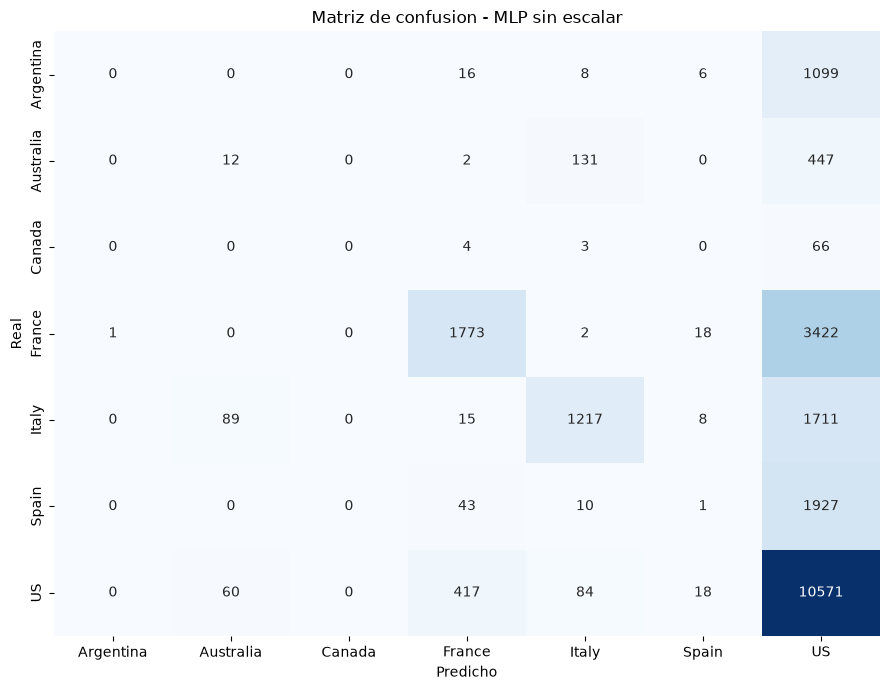

,Argentina,Australia,Canada,France,Italy,Spain,US
Argentina,0,0,0,16,8,6,1099
Australia,0,12,0,2,131,0,447
Canada,0,0,0,4,3,0,66
France,1,0,0,1773,2,18,3422
Italy,0,89,0,15,1217,8,1711
Spain,0,0,0,43,10,1,1927
US,0,60,0,417,84,18,10571


In [21]:
cm = confusion_matrix(y_test_el, y_pred_el)
clases = le_country.classes_

plt.figure(figsize=(9, 7))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=clases, yticklabels=clases, cbar=False)
plt.xlabel('Predicho')
plt.ylabel('Real')
plt.title('Matriz de confusion - MLP sin escalar')
plt.tight_layout()
plt.show()

pd.DataFrame(cm, index=clases, columns=clases)

Leyendo la matriz por columnas se ve lo que hace realmente el modelo: la columna **US** concentra casi todo. Los 1.129 vinos argentinos fueron a parar mayoritariamente a US (1.099), y lo mismo pasa con España (1.927 de sus casos a US) y Canadá, que no recibió **ninguna** predicción.

Es el comportamiento típico de un clasificador que no aprendió a separar: ante clases desbalanceadas y features sin escalar, apuesta casi siempre a la mayoritaria. Por eso el 58,56% de exactitud de la consigna 1 convive con un F1 macro de 0,25.

Como contraste, el modelo escalado sí distingue Argentina:

In [22]:
pred_arg_esc = (y_pred_esc == codigo_argentina).sum()
acierto_arg_esc = ((y_pred_esc == codigo_argentina) & (y_test_el == codigo_argentina)).sum()

comparacion = pd.DataFrame([
    ['Sin escalar (consigna)', predijo_argentina, aciertos_argentina],
    ['Con StandardScaler', pred_arg_esc, acierto_arg_esc],
], columns=['Modelo', 'Predijo Argentina', 'Acerto'])

print(f'Casos reales de Argentina en el test: {reales_argentina}')
comparacion

Casos reales de Argentina en el test: 1129


,Modelo,Predijo Argentina,Acerto
0,Sin escalar (consigna),1,0
1,Con StandardScaler,1152,1129


### Consigna 3 — País con la precision más alta

> De la ejecución del modelo anterior, el país con la precision más alta es:
>
> - Canada
> - Italy
> - France
> - Argentina

La **precision** de una clase responde: de todas las veces que el modelo predijo ese país, ¿qué proporción acertó? Es la columna correspondiente de la matriz de confusión: `TP / (TP + FP)`. Sale directo del `classification_report`.

In [23]:
print(classification_report(y_test_el, y_pred_el,
                            target_names=le_country.classes_,
                            zero_division=0))

              precision    recall  f1-score   support

   Argentina       0.00      0.00      0.00      1129
   Australia       0.07      0.02      0.03       592
      Canada       0.00      0.00      0.00        73
      France       0.78      0.34      0.47      5216
       Italy       0.84      0.40      0.54      3040
       Spain       0.02      0.00      0.00      1981
          US       0.55      0.95      0.70     11150

    accuracy                           0.59     23181
   macro avg       0.32      0.24      0.25     23181
weighted avg       0.55      0.59      0.51     23181



In [24]:
from sklearn.metrics import precision_score

precisiones = pd.Series(
    precision_score(y_test_el, y_pred_el, average=None, zero_division=0),
    index=le_country.classes_
).sort_values(ascending=False)

print(precisiones.round(4).to_string())
print(f'\nLa precision mas alta es la de: {precisiones.idxmax()} ({precisiones.max():.4f})')

Italy        0.8364
France       0.7811
US           0.5493
Australia    0.0745
Spain        0.0196
Argentina    0.0000
Canada       0.0000

La precision mas alta es la de: Italy (0.8364)


**Respuesta: Italy**, con una precision de 0,84.

#### Por qué gana Italy, y por qué eso no significa que sea la mejor clase

| País | Precision | Recall |
|---|---|---|
| **Italy** | **0,84** | 0,40 |
| France | 0,78 | 0,34 |
| US | 0,55 | 0,95 |
| Australia | 0,07 | 0,02 |
| Spain | 0,02 | 0,00 |
| Argentina | 0,00 | 0,00 |
| Canada | 0,00 | 0,00 |

Italy tiene la precision más alta pero un recall de apenas 0,40: **de los 3.040 vinos italianos del test solo reconoce el 40%**. Lo que la precision alta dice es que el modelo es *conservador* con Italy — predice esa clase pocas veces (1.455 en total), pero cuando lo hace suele acertar.

US es el caso opuesto: precision 0,55 y recall 0,95. Predice US para casi todo, así que atrapa el 95% de los vinos estadounidenses a costa de arrastrar miles de casos de otros países.

Argentina y Canada tienen precision 0 porque el modelo prácticamente nunca las predice (consigna 2). Cuando una clase no recibe ninguna predicción, la precision queda indefinida —división por cero— y `zero_division=0` la reporta como 0.

Es un buen recordatorio de que **precision y recall se leen juntas**: una precision alta con recall bajo describe un modelo tímido, no uno bueno.

### Consigna 4 — Agrandar la red a (100, 200)

> Si el modelo anterior tuviera 100 neuronas en la primer capa oculta, y 200 en la segunda, la diferencia en valor absoluto del Accuracy con la primera versión del MLP, sería de:
>
> - Aproximadamente el 38%
> - Aproximadamente el 12%
> - El 0% ya que no hubo mejora
> - Ninguno de los anteriores

Se cambia solo `hidden_layer_sizes` a `(100, 200)`. El resto queda igual: `max_iter=100`, `random_state=17`, sin escalar. Esta celda tarda cerca de medio minuto: la red tiene muchos más parámetros que la anterior.

In [25]:
mlp_grande = MLPClassifier(hidden_layer_sizes=(100, 200), max_iter=100, random_state=17)
mlp_grande.fit(X_train_el, y_train_el)

y_pred_grande = mlp_grande.predict(X_test_el)
accuracy_grande = accuracy_score(y_test_el, y_pred_grande)

diferencia = abs(accuracy_grande - accuracy_el)

print(f'MLP (6, 12)    : {accuracy_el:.4f}   ({accuracy_el*100:.2f}%)')
print(f'MLP (100, 200) : {accuracy_grande:.4f}   ({accuracy_grande*100:.2f}%)')
print(f'\nDiferencia en valor absoluto: {diferencia:.4f}  ->  {diferencia*100:.2f} puntos porcentuales')

MLP (6, 12)    : 0.5856   (58.56%)
MLP (100, 200) : 0.9645   (96.45%)

Diferencia en valor absoluto: 0.3789  ->  37.89 puntos porcentuales


/opt/anaconda3/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


**Respuesta: aproximadamente el 38%** (37,89 puntos porcentuales).

#### Por qué el salto es tan grande

Contando los parámetros de cada red se entiende de dónde sale la diferencia.

In [26]:
def contar_parametros(modelo):
    return sum(w.size for w in modelo.coefs_) + sum(b.size for b in modelo.intercepts_)

resumen_arq = pd.DataFrame([
    ['(6, 12)',    accuracy_el,     contar_parametros(mlp_paises), mlp_paises.n_iter_, mlp_paises.loss_],
    ['(100, 200)', accuracy_grande, contar_parametros(mlp_grande), mlp_grande.n_iter_, mlp_grande.loss_],
], columns=['Arquitectura', 'Accuracy', 'Parametros', 'n_iter_', 'Loss final'])

resumen_arq

,Arquitectura,Accuracy,Parametros,n_iter_,Loss final
0,"(6, 12)",0.585566,223,73,1.198746
1,"(100, 200)",0.964497,22407,100,0.213010


La red chica tenía apenas 6 neuronas en la primera capa para comprimir 7 features de escalas muy distintas: no le alcanzaba la **capacidad** — es un caso de subajuste de manual. Con 100 y 200 neuronas la red sí puede representar las fronteras que separan los países, incluso sin escalar.

Dos detalles del entrenamiento que conviene notar:

- La red chica cortó en `n_iter_ = 73`, por falta de mejora. La grande llegó a las 100 iteraciones **sin converger** (`ConvergenceWarning`): con más `max_iter` probablemente mejoraría todavía más.
- Esos 37,89 puntos se ganan a costa de multiplicar los parámetros y el tiempo de entrenamiento. Vale compararlo con lo que se conseguía **escalando** la red chica: 99,11% con la arquitectura original de 6 y 12 neuronas. Escalar salía gratis y daba un resultado mejor que agrandar la red.

### Consigna 5 — F1-Score más bajo y Recall más alto

> Considerando las 100 y 200 neuronas para la primer y segunda capa, el F1-Score de ________ es el más bajo y el Recall de __________ es el más alto
>
> - US y Canada
> - Argentina y Spain
> - Canada y Australia
> - Spain y France
> - Ninguna de las anteriores

Se evalúa el modelo `(100, 200)` de la consigna anterior y se ordenan las dos métricas por separado.

In [27]:
print(classification_report(y_test_el, y_pred_grande,
                            target_names=le_country.classes_,
                            zero_division=0, digits=4))

              precision    recall  f1-score   support

   Argentina     0.9805    0.8893    0.9327      1129
   Australia     0.8841    0.8378    0.8604       592
      Canada     0.8684    0.4521    0.5946        73
      France     0.9571    0.9711    0.9640      5216
       Italy     0.9748    0.9559    0.9653      3040
       Spain     0.9159    0.9177    0.9168      1981
          US     0.9766    0.9898    0.9832     11150

    accuracy                         0.9645     23181
   macro avg     0.9368    0.8591    0.8881     23181
weighted avg     0.9643    0.9645    0.9640     23181



In [28]:
from sklearn.metrics import recall_score

f1_por_clase = pd.Series(
    f1_score(y_test_el, y_pred_grande, average=None, zero_division=0),
    index=le_country.classes_)

recall_por_clase = pd.Series(
    recall_score(y_test_el, y_pred_grande, average=None, zero_division=0),
    index=le_country.classes_)

print('F1-Score, de menor a mayor:')
print(f1_por_clase.sort_values().round(4).to_string())
print(f'\n-> F1 mas BAJO: {f1_por_clase.idxmin()} ({f1_por_clase.min():.4f})')

print('\nRecall, de mayor a menor:')
print(recall_por_clase.sort_values(ascending=False).round(4).to_string())
print(f'\n-> Recall mas ALTO: {recall_por_clase.idxmax()} ({recall_por_clase.max():.4f})')

F1-Score, de menor a mayor:
Canada       0.5946
Australia    0.8604
Spain        0.9168
Argentina    0.9327
France       0.9640
Italy        0.9653
US           0.9832

-> F1 mas BAJO: Canada (0.5946)

Recall, de mayor a menor:
US           0.9898
France       0.9711
Italy        0.9559
Spain        0.9177
Argentina    0.8893
Australia    0.8378
Canada       0.4521

-> Recall mas ALTO: US (0.9898)


**Respuesta: Ninguna de las anteriores.**

Los valores que salen son:

- F1-Score más bajo: **Canada** (0,5946)
- Recall más alto: **US** (0,9898)

O sea, la combinación correcta sería *"Canada y US"*, y esa opción no está entre las disponibles. La única que menciona a los dos países es **"US y Canada"**, pero en el orden inverso al que pide la frase: diría que el F1 más bajo es el de US —cuando US tiene justamente el **más alto**, 0,9832— y que el recall más alto es el de Canada, que tiene el **más bajo**, 0,4521. Está exactamente al revés.

#### Por qué Canada queda última y US primero

| País | Casos en test | Precision | Recall | F1 |
|---|---|---|---|---|
| **Canada** | 73 | 0,8684 | **0,4521** | **0,5946** |
| **US** | 11.150 | 0,9766 | **0,9898** | 0,9832 |

Canada tiene apenas **73 casos** en el test contra los 11.150 de US. Con tan pocos ejemplos la red no llega a aprender el patrón y solo reconoce el 45% de los vinos canadienses; su precision no es mala (0,87), pero el recall bajo hunde el F1, que es la media armónica de ambas.

Es el mismo desbalance de siempre, ahora en un modelo bueno: la exactitud global de 96,45% oculta que la clase más chica sigue reconociéndose apenas la mitad de las veces. Por eso el **macro avg** del F1 (0,8881) queda bastante por debajo del **weighted avg** (0,9640) — el macro trata a Canada igual que a US, el weighted la diluye.

### Consigna 6 — MLP Regresor sobre `data_imputados`

> Considerando el DataFrame `data_imputados`: crea un MLP Regresor con 1 capa oculta de 100 neuronas, 1000 iteraciones como máximo, un valor de 0.001 de alpha y una semilla de aleatoriedad de 17. El R2 es de:
>
> - 0.82
> - 0.45
> - 0.75
> - Ninguno de los anteriores

Cambia el problema: ahora es **regresión** — se predice `price` a partir de las otras columnas. Parámetros: `hidden_layer_sizes=(100,)`, `max_iter=1000`, `alpha=0.001`, `random_state=17`.

In [29]:
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

mlp_precio = MLPRegressor(hidden_layer_sizes=(100,), max_iter=1000,
                          alpha=0.001, random_state=17)
mlp_precio.fit(X_train_im, y_train_im)

y_pred_im = mlp_precio.predict(X_test_im)
r2 = r2_score(y_test_im, y_pred_im)

print(f'R2   : {r2:.4f}')
print(f'RMSE : {np.sqrt(mean_squared_error(y_test_im, y_pred_im)):.4f}')
print(f'MAE  : {mean_absolute_error(y_test_im, y_pred_im):.4f}')
print(f'\nn_iter_: {mlp_precio.n_iter_} de 1000 | loss final: {mlp_precio.loss_:.2f}')

R2   : 0.0415
RMSE : 47.6279
MAE  : 20.4291

n_iter_: 29 de 1000 | loss final: 783.66


**Respuesta: Ninguno de los anteriores.** El R² da **0,0415**, muy lejos de 0,82, 0,45 y 0,75.

#### Qué significa un R² de 0,04

El R² mide qué proporción de la varianza del precio explica el modelo. **0 equivale a predecir siempre la media**; 1 sería predicción perfecta.

Con 0,0415 el modelo explica el **4% de la varianza**: apenas mejor que responder "35,36 dólares" —la media— para todos los vinos. El RMSE de 47,63 dólares sobre precios cuya media es 35 confirma que las predicciones no sirven.

In [30]:
# Comparacion contra el baseline de predecir siempre la media
media_train = y_train_im.mean()
pred_baseline = np.full(len(y_test_im), media_train)

print(f'{"Modelo":28} {"R2":>9} {"RMSE":>10}')
print(f'{"Predecir la media":28} {r2_score(y_test_im, pred_baseline):>9.4f} '
      f'{np.sqrt(mean_squared_error(y_test_im, pred_baseline)):>10.2f}')
print(f'{"MLPRegressor (consigna)":28} {r2:>9.4f} {np.sqrt(mean_squared_error(y_test_im, y_pred_im)):>10.2f}')

Modelo                              R2       RMSE
Predecir la media              -0.0001      48.65
MLPRegressor (consigna)         0.0415      47.63


#### Por qué da tan mal

Se juntan tres razones, y las tres estaban anunciadas antes de entrenar:

1. **Sin escalado.** Es el mismo problema de las consignas anteriores: `winery` y `region_1` codificados llegan a valores de cuatro y cinco cifras y dominan la suma ponderada. El entrenamiento cortó en **`n_iter_ = 29`** de 1000 —por falta de mejora, no por converger—: el optimizador se estancó enseguida.

2. **El target está imputado con la media.** Como se anotó en la sección 5, todas las filas cuyo `price` era nulo llevan ahora el valor 35,36. Se le está enseñando al modelo a predecir la media en una porción de los datos.

3. **Las features codificadas con etiquetas no informan sobre el precio.** Que una bodega tenga el código 8.234 no guarda ninguna relación con lo que cuesta su vino; el orden de los enteros es arbitrario. Para este problema harían falta one-hot, *target encoding*, o directamente aprovechar `description` y `points`, que sí correlacionan con el precio.

Como referencia, escalando los datos —lo que la consigna no pide— el R² sube a 0,2928: mejor, pero todavía flojo. El problema de fondo es la codificación, no solo la escala.

### Consigna 7 — Accuracy del modelo anterior

> Considerando el modelo anterior, el Accuracy del modelo es de:
>
> - 96%
> - 35%
> - 86%
> - Ninguna de las anteriores

Esta consigna admite dos lecturas, según a qué modelo se refiera "el anterior". Se resuelven las dos.

#### Lectura A — "el anterior" es el `MLPRegressor` de la consigna 6

Es la lectura literal: el modelo inmediatamente anterior. Pero **la exactitud no está definida para regresión**: mide la proporción de predicciones correctas, y en un problema continuo ninguna predicción cae exactamente sobre el valor real.

In [31]:
from sklearn.metrics import accuracy_score

# Cuantas predicciones del regresor coinciden EXACTAMENTE con el precio real
coincidencias = (y_pred_im == y_test_im.values).sum()
print(f'Predicciones exactas: {coincidencias} de {len(y_test_im):,}')

# accuracy_score directamente se niega a evaluar un target continuo
try:
    accuracy_score(y_test_im, y_pred_im)
except ValueError as e:
    print(f'\naccuracy_score falla -> ValueError: {e}')

# Lo que devuelve .score() en un regresor NO es accuracy, es R2
print(f'\nmlp_precio.score(X_test, y_test) = {mlp_precio.score(X_test_im, y_test_im):.4f}')
print(f'r2_score(y_test, y_pred)         = {r2_score(y_test_im, y_pred_im):.4f}')
print('Son el mismo numero: en un regresor, .score() devuelve R2.')

Predicciones exactas: 0 de 24,855

accuracy_score falla -> ValueError: continuous is not supported

mlp_precio.score(X_test, y_test) = 0.0415
r2_score(y_test, y_pred)         = 0.0415
Son el mismo numero: en un regresor, .score() devuelve R2.


Bajo esta lectura la respuesta es **Ninguna de las anteriores**: la exactitud no aplica, y si se toma el `.score()` del regresor como si lo fuera, da 0,0415 → **4%**, que tampoco está entre las opciones.

#### Lectura B — "el anterior" es el `MLPClassifier` de (100, 200)

Es el último modelo al que sí se le puede medir exactitud, el de las consignas 4 y 5.

In [32]:
print(f'MLPClassifier (100, 200) -> Accuracy = {accuracy_grande:.4f}  ->  {accuracy_grande*100:.2f}%')

MLPClassifier (100, 200) -> Accuracy = 0.9645  ->  96.45%


Bajo esta lectura la respuesta es **96%**, que coincide de forma exacta con una de las opciones ofrecidas.

#### Cuál marcar

| Lectura | Modelo | Resultado | Opción |
|---|---|---|---|
| A (literal) | `MLPRegressor` de la consigna 6 | la exactitud no aplica; `.score()` = R² = 0,0415 | Ninguna de las anteriores |
| B | `MLPClassifier` `(100, 200)` | Accuracy = 0,9645 | 96% |

Que **96% coincida exactamente** con el accuracy del clasificador grande es un indicio fuerte de que el cuestionario apunta a la lectura B — sería mucha casualidad que ofrezca ese valor si la respuesta buscada fuera "ninguna".

Si en el formulario esta pregunta viene inmediatamente después de la del R², conviene marcar **96%**. La lectura A queda documentada porque el punto conceptual vale: **un regresor no tiene accuracy**, y su `.score()` devuelve R², no exactitud — confundir las dos cosas es un error frecuente.